In [1]:
import os, subprocess, sys

REPO_URL = "https://github.com/hkha0801-sketch/MetricGAN-plus-.git"
REPO_DIR = "MetricGAN-plus-"

if not os.path.isdir(REPO_DIR):
    subprocess.check_call(["git", "clone", REPO_URL])
    print(f"Cloned {REPO_URL}")
else:
    print(f"Repo already exists at ./{REPO_DIR}")

# Add the repo root to Python path so local modules are importable
repo_root = os.path.abspath(REPO_DIR)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
    print(f"Added {repo_root} to sys.path")

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "pesq", "soundfile", "librosa", "joblib", "tqdm", "scipy"])
print("Dependencies installed.")


Cloning into 'MetricGAN-plus-'...


Cloned https://github.com/hkha0801-sketch/MetricGAN-plus-.git
Added /kaggle/working/MetricGAN-plus- to sys.path
Dependencies installed.


In [2]:
import os
import sys
import glob
import json
import time
import shutil
import random
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import IPython.display as ipd

import torch
import torch.nn as nn
import torchaudio

from model import Generator, Discriminator
from train import Trainer
from dataloader import create_dataloader, Generator_train_dataset, Discriminator_train_dataset
from signal_processing import get_spec_and_phase, transform_spec_to_wav
from metric_functions.get_metric_scores import get_pesq_parallel, get_csig_parallel, get_cbak_parallel, get_covl_parallel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using PyTorch device: {device}")

def setup_seed(seed=1):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

setup_seed(1)

os.chdir(os.path.join(os.getcwd().split(REPO_DIR)[0], REPO_DIR) if REPO_DIR not in os.getcwd() else os.getcwd())
print(f"Working directory: {os.getcwd()}")

Using PyTorch device: cuda
Working directory: /kaggle/working/MetricGAN-plus-


In [3]:
import os, glob, shutil, zipfile

KAGGLE_DATASET_HINT = "NOISE SPEECH"
KAGGLE_INPUT_ROOT = "/kaggle/input"


def _norm(name):
    return name.strip().lower()


def find_train_test_dirs(input_root):
    """Dò toàn bộ /kaggle/input để tìm thư mục cha có chứa 2 thư mục con
    TRAIN (train) và TEST (test) — đây chính là dataset dữ liệu tiếng Việt
    đã được Add Input sẵn trong Kaggle, không cần tải từ Hugging Face."""
    if not os.path.isdir(input_root):
        return None, None

    best_train, best_test = None, None
    for root, dirs, files in os.walk(input_root):
        dir_map = {_norm(d): d for d in dirs}
        if "train" in dir_map and "test" in dir_map:
            best_train = os.path.join(root, dir_map["train"])
            best_test = os.path.join(root, dir_map["test"])
            # Ưu tiên thư mục có tên khớp gợi ý (KAGGLE_DATASET_HINT)
            if _norm(KAGGLE_DATASET_HINT) in _norm(root):
                break
    return best_train, best_test


def maybe_extract_zip(dir_path):
    """Nếu thư mục TRAIN/TEST rỗng nhưng có sẵn TRAIN.zip/TEST.zip cạnh đó, giải nén ra
    một thư mục làm việc riêng (Kaggle input là read-only nên không giải nén tại chỗ)."""
    if dir_path and len(os.listdir(dir_path)) > 0:
        return dir_path

    parent = os.path.dirname(dir_path)
    base = os.path.basename(dir_path)
    zip_candidates = glob.glob(os.path.join(parent, f"{base}*.zip"))
    if not zip_candidates:
        return dir_path

    zip_path = zip_candidates[0]
    extract_to = os.path.join("/kaggle/working", "extracted", base)
    os.makedirs(extract_to, exist_ok=True)
    print(f" {dir_path} trống — giải nén {zip_path} -> {extract_to}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)
    return extract_to


def classify_and_copy(src_dir, dest_root):
    """Tổ chức dữ liệu từ src_dir (có thể lồng nhiều cấp thư mục con) vào
    dest_root/clean và dest_root/noisy.
    - Nếu src_dir đã có sẵn 2 thư mục con clean/noisy thì copy trực tiếp.
    - Ngược lại, phân loại theo tên file/thư mục (clean/sạch vs noise, noisy/nhiễu)."""
    clean_dest = os.path.join(dest_root, "clean")
    noisy_dest = os.path.join(dest_root, "noisy")
    os.makedirs(clean_dest, exist_ok=True)
    os.makedirs(noisy_dest, exist_ok=True)

    if len(glob.glob(os.path.join(clean_dest, "*.wav"))) > 0 and \
       len(glob.glob(os.path.join(noisy_dest, "*.wav"))) > 0:
        print(f"   Dữ liệu tại {dest_root} đã có sẵn, bỏ qua.")
        return

    all_wavs = glob.glob(os.path.join(src_dir, "**", "*.wav"), recursive=True)
    n_clean, n_noisy, n_unknown = 0, 0, 0
    clean_tokens = ["clean", "sach", "sạch"]
    noisy_tokens = ["noise", "noisy", "nhieu", "nhiễu", "nhiễu"]

    for f in all_wavs:
        lower = f.lower()
        if any(t in lower for t in clean_tokens):
            shutil.copy(f, os.path.join(clean_dest, os.path.basename(f)))
            n_clean += 1
        elif any(t in lower for t in noisy_tokens):
            shutil.copy(f, os.path.join(noisy_dest, os.path.basename(f)))
            n_noisy += 1
        else:
            n_unknown += 1

    print(f"   ✓ clean: {n_clean} | noisy: {n_noisy} | không xác định: {n_unknown}")
    if n_unknown > 0:
        print(" Một số file không xác định được clean/noisy theo tên — "
              "kiểm tra lại cấu trúc thư mục gốc nếu số liệu train quá ít.")


base_data_path = "data/VCTK_DEMAND"
train_clean_dir = os.path.join(base_data_path, "train", "clean")
train_noisy_dir = os.path.join(base_data_path, "train", "noisy")
test_clean_dir = "/kaggle/input/datasets/khabiphmhng/testclean/inputTestClean"
test_noisy_dir = os.path.join(base_data_path, "test", "noisy")
for d in [train_clean_dir, train_noisy_dir, test_clean_dir, test_noisy_dir]:
    os.makedirs(d, exist_ok=True)

if len(glob.glob(os.path.join(train_clean_dir, "*.wav"))) > 0 and \
   len(glob.glob(os.path.join(test_clean_dir, "*.wav"))) > 0:
    print("Dữ liệu đã được tổ chức sẵn tại data/VCTK_DEMAND, bỏ qua bước dò tìm.")
else:
    kaggle_train_dir, kaggle_test_dir = find_train_test_dirs(KAGGLE_INPUT_ROOT)

    if kaggle_train_dir is None or kaggle_test_dir is None:
        raise FileNotFoundError(
            "Không tìm thấy thư mục TRAIN/TEST trong /kaggle/input. "
            "Hãy chắc chắn bạn đã Add Input dataset chứa dữ liệu tiếng Việt "
            "(vd. dataset 'NOISE SPEECH') vào notebook này trước khi chạy cell này."
        )

    print(f"Tìm thấy dữ liệu TRAIN tiếng Việt tại: {kaggle_train_dir}")
    print(f"Tìm thấy dữ liệu TEST  tiếng Việt tại: {kaggle_test_dir}")

    kaggle_train_dir = maybe_extract_zip(kaggle_train_dir)
    kaggle_test_dir = maybe_extract_zip(kaggle_test_dir)

    print("\n1) Tổ chức dữ liệu Fine-tune (train)...")
    classify_and_copy(kaggle_train_dir, os.path.join(base_data_path, "train"))

    print("2) Tổ chức dữ liệu Inference (test)...")
    classify_and_copy(kaggle_test_dir, os.path.join(base_data_path, "test"))

print("\nDataset counts:")
print(f"  Train clean: {len(glob.glob(os.path.join(train_clean_dir, '*.wav')))} files")
print(f"  Train noisy: {len(glob.glob(os.path.join(train_noisy_dir, '*.wav')))} files")
print(f"  Test clean:  {len(glob.glob(os.path.join(test_clean_dir, '*.wav')))} files")
print(f"  Test noisy:  {len(glob.glob(os.path.join(test_noisy_dir, '*.wav')))} files")


Tìm thấy dữ liệu TRAIN tiếng Việt tại: /kaggle/input/datasets/khabiphmhng/noise-speech/NOISE SPEECH/TRAIN
Tìm thấy dữ liệu TEST  tiếng Việt tại: /kaggle/input/datasets/khabiphmhng/noise-speech/NOISE SPEECH/TEST 

1) Tổ chức dữ liệu Fine-tune (train)...
   ✓ clean: 8460 | noisy: 8460 | không xác định: 0
2) Tổ chức dữ liệu Inference (test)...
   ✓ clean: 0 | noisy: 940 | không xác định: 0

Dataset counts:
  Train clean: 8460 files
  Train noisy: 8460 files
  Test clean:  940 files
  Test noisy:  940 files


Clean audio sample: data/VCTK_DEMAND/train/clean/AIBDV003-N01.wav


/usr/local/lib/python3.12/dist-packages/torch/functional.py:681: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:874.)
  return _VF.stft(  # type: ignore[attr-defined]


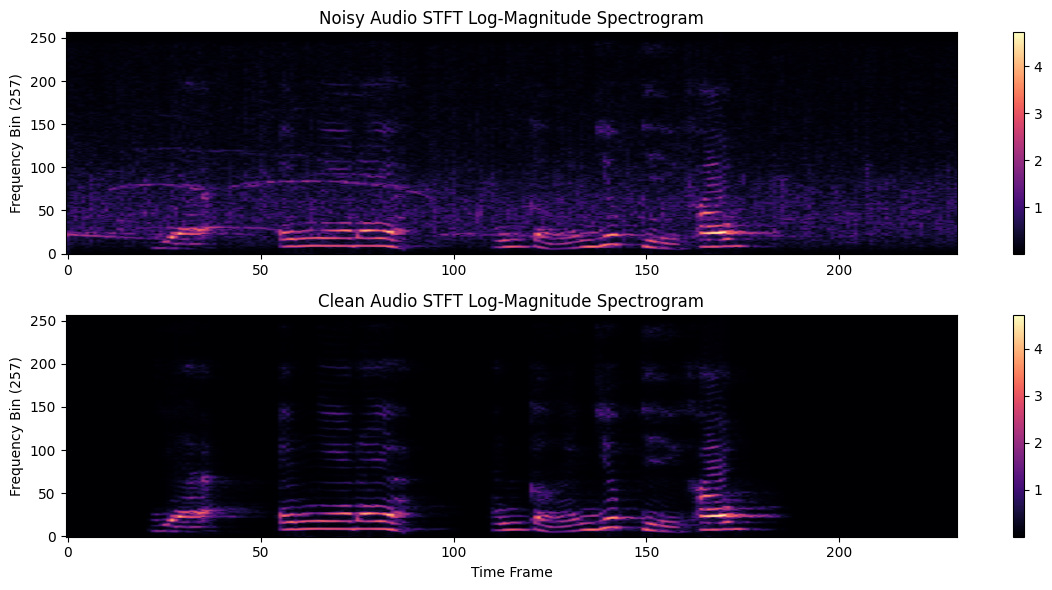

Listen to Noisy Audio Sample:


Listen to Clean Audio Sample:


In [4]:
clean_sample_files = sorted(glob.glob("data/VCTK_DEMAND/train/clean/*.wav")) or sorted(glob.glob("inputClean/*.wav"))
noisy_sample_files = sorted(glob.glob("data/VCTK_DEMAND/train/noisy/*.wav")) or sorted(glob.glob("inputTest/*.wav"))

if clean_sample_files and noisy_sample_files:
    clean_path = clean_sample_files[0]
    noisy_path = noisy_sample_files[0]

    print(f"Clean audio sample: {clean_path}")
    clean_wav, sr_clean = torchaudio.load(clean_path)
    noisy_wav, sr_noisy = torchaudio.load(noisy_path)

    clean_mag, clean_phase = get_spec_and_phase(clean_wav)
    noisy_mag, noisy_phase = get_spec_and_phase(noisy_wav)

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))

    im0 = axes[0].imshow(noisy_mag.squeeze().T.numpy(), aspect='auto', origin='lower', cmap='magma')
    axes[0].set_title("Noisy Audio STFT Log-Magnitude Spectrogram")
    axes[0].set_ylabel("Frequency Bin (257)")
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(clean_mag.squeeze().T.numpy(), aspect='auto', origin='lower', cmap='magma')
    axes[1].set_title("Clean Audio STFT Log-Magnitude Spectrogram")
    axes[1].set_xlabel("Time Frame")
    axes[1].set_ylabel("Frequency Bin (257)")
    fig.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.show()

    print("Listen to Noisy Audio Sample:")
    ipd.display(ipd.Audio(noisy_wav.numpy().squeeze(), rate=sr_noisy))

    print("Listen to Clean Audio Sample:")
    ipd.display(ipd.Audio(clean_wav.numpy().squeeze(), rate=sr_clean))
else:
    print("No audio files found for visualization. Please check dataset path.")

In [5]:
generator = Generator(causal=False).to(device)
discriminator = Discriminator().to(device)

g_params = sum(p.numel() for p in generator.parameters()) / 1e6
d_params = sum(p.numel() for p in discriminator.parameters()) / 1e6

print(f"Generator parameter count:     {g_params:.3f}M")
print(f"Discriminator parameter count: {d_params:.3f}M")

dummy_noisy = torch.randn(1, 100, 257).to(device)
dummy_mask = generator(dummy_noisy)
print(f"Dummy noisy input shape: {dummy_noisy.shape}")
print(f"Predicted mask shape:    {dummy_mask.shape}")

Generator parameter count:     1.896M
Discriminator parameter count: 0.277M
Dummy noisy input shape: torch.Size([1, 100, 257])
Predicted mask shape:    torch.Size([1, 100, 257])


In [6]:

import urllib.request

CKPT_URL = "https://raw.githubusercontent.com/hkha0801-sketch/PESEM-VS/main/checkpoints/MetricGAN%2B_EN.pth"
PRETRAINED_CKPT_PATH = "pretrained/MetricGAN+_EN.pth"

os.makedirs(os.path.dirname(PRETRAINED_CKPT_PATH), exist_ok=True)
if not os.path.exists(PRETRAINED_CKPT_PATH):
    print(f"Đang tải checkpoint gốc từ: {CKPT_URL}")
    urllib.request.urlretrieve(CKPT_URL, PRETRAINED_CKPT_PATH)
    print(f"✓ Đã lưu checkpoint tại: {PRETRAINED_CKPT_PATH}")
else:
    print(f"Checkpoint đã tồn tại tại: {PRETRAINED_CKPT_PATH}")

from pathlib import Path

class TrainingArgs:
    def __init__(self, exp_name='exp_finetune', target_metric='pesq', epochs=20, batch_size=1, lr=3e-5):
        self.exp_name = exp_name
        self.device = str(device)          
        self.output_path = 'results'
        self.base_path = 'data/VCTK_DEMAND'
        self.target_metric = target_metric
        self.epochs = epochs               
        self.batch_size = batch_size
        self.num_of_sampling = 100       
        self.num_of_val_sample = 50      
        self.hist_portion = 0.2
        self.lr = lr                      
        self.eval_per_epoch = 1
        self.skip_val_epoch = 1
        self.seed = 1
        self.causal = False
        self.num_workers = 0
        self.val_speaker = []

args = TrainingArgs(exp_name='exp_finetune', target_metric='pesq', epochs=20, batch_size=1, lr=3e-5)

train_noisy_path = f'{args.base_path}/train/noisy/'
train_clean_path = f'{args.base_path}/train/clean/'
train_enhan_path = f'{args.output_path}/{args.exp_name}/enhanced_wavs/'
test_noisy_path = f'{args.base_path}/test/noisy/'
test_clean_path = f'{args.base_path}/test/clean/'

model_output_path = Path(args.output_path, args.exp_name, 'model')
log_output_path = Path(args.output_path, args.exp_name)
model_output_path.mkdir(parents=True, exist_ok=True)
log_output_path.mkdir(parents=True, exist_ok=True)

data_paths = {
    'train_noisy': train_noisy_path,
    'train_clean': train_clean_path,
    'train_enhan': train_enhan_path,
    'test_noisy': test_noisy_path,
    'test_clean': test_clean_path,
    'model_output': model_output_path,
    'log_output': log_output_path
}

print(f"Bắt đầu FINE-TUNE MetricGAN+ ({args.epochs} epochs) trên {args.device.upper()}...")
print(f"Checkpoint gốc: {PRETRAINED_CKPT_PATH}")
print(f"Output directory: results/{args.exp_name}")
print("=" * 65)


class FinetuneTrainer(Trainer):
    """Kế thừa Trainer gốc của repo — điểm khác biệt duy nhất: nạp
    checkpoint pretrained (MetricGAN+_EN.pth) vào Generator & Discriminator
    NGAY SAU KHI khởi tạo, thay vì bắt đầu từ trọng số ngẫu nhiên.
    => Đây là Fine-tune, KHÔNG phải train from scratch."""

    def __init__(self, args, data_paths, pretrained_path):
        self.pretrained_path = pretrained_path
        super().__init__(args, data_paths)

    def init_model_optim(self):
        super().init_model_optim()  # khởi tạo G, D, optimizer như bình thường
        if os.path.exists(self.pretrained_path):
            ckpt = torch.load(self.pretrained_path, map_location=self.device, weights_only=False)
            self.G.load_state_dict(ckpt['generator'])
            self.D.load_state_dict(ckpt['discriminator'])
            print(f"Đã nạp trọng số pretrained (epoch gốc: {ckpt.get('epoch')}, "
                  f"stats gốc: {ckpt.get('stats')}) — sẵn sàng Fine-tune.")
            # Không nạp lại optimizer state của checkpoint gốc vì LR fine-tune
            # thường khác LR lúc train gốc — dùng optimizer mới với LR đã cấu hình ở args.lr
        else:
            print(f"Không tìm thấy checkpoint tại {self.pretrained_path} — sẽ train từ đầu (random init).")

    def init_noisy_score(self):
        print("⏳ Đang tính điểm baseline (metric) cho tập noisy...")
        n_cpus = max(1, min(4, os.cpu_count() or 1))
        self.noisy_set_scores = {}
        Noised_name = glob.glob(self.train_noisy_path + '/*.wav')
        if len(Noised_name) == 0:
            print("Không tìm thấy file .wav trong data/VCTK_DEMAND/train/noisy/")
            return
        train_score_C_N = self.target_metric_func(self.train_clean_path, Noised_name, n_jobs=n_cpus)
        for path, score in zip(Noised_name, train_score_C_N):
            self.noisy_set_scores[path] = score
        print(f"✓ Đã tính xong baseline cho {len(Noised_name)} mẫu.\n")

    def train(self):
        start_time = time.time()
        self.epoch = 1
        self.historical_set = []

        total_samples = len(self.generator_train_paths)
        print(f"Bắt đầu Fine-tune với {total_samples} mẫu training...")
        print("=" * 65)

        for epoch in range(1, self.args.epochs + 1):
            self.epoch = epoch
            epoch_start = time.time()
            print(f"\n▶ Epoch [{epoch}/{self.args.epochs}] Fine-tuning...")

            random.shuffle(self.generator_train_paths)
            sample_count = min(len(self.generator_train_paths), self.args.num_of_sampling)
            genloader = create_dataloader(
                self.generator_train_paths[0:sample_count],
                self.train_noisy_path,
                num_target_metric=1, loader='G', batch_size=self.args.batch_size, num_workers=self.args.num_workers
            )

            self.train_one_epoch(genloader)

            elapsed = time.time() - epoch_start
            print(f"Epoch [{epoch}/{self.args.epochs}] hoàn tất trong {elapsed:.1f}s")

            log_file = os.path.join(self.log_output_path, 'log.txt')
            if os.path.exists(log_file):
                with open(log_file, 'r') as f:
                    eval_lines = [line.strip() for line in f.readlines() if f"Epoch:{epoch}" in line]
                    if eval_lines:
                        print(f"{eval_lines[-1]}")

        total_time = (time.time() - start_time) / 60
        print("\n" + "=" * 65)
        print(f"Fine-tune hoàn tất! Tổng thời gian: {total_time:.2f} phút")
        print(f"Model tốt nhất được lưu tại: {model_output_path}/best_model.pth")


trainer = FinetuneTrainer(args, data_paths, pretrained_path=PRETRAINED_CKPT_PATH)
trainer.train()


Đang tải checkpoint gốc từ: https://raw.githubusercontent.com/hkha0801-sketch/PESEM-VS/main/checkpoints/MetricGAN%2B_EN.pth
✓ Đã lưu checkpoint tại: pretrained/MetricGAN+_EN.pth
Bắt đầu FINE-TUNE MetricGAN+ (20 epochs) trên CUDA...
Checkpoint gốc: pretrained/MetricGAN+_EN.pth
Output directory: results/exp_finetune
Đã nạp trọng số pretrained (epoch gốc: 701, stats gốc: {'pesq': np.float64(3.148125047099243), 'csig': np.float64(4.091025806313497), 'cbak': np.float64(3.1616192833785526), 'covl': np.float64(3.6066304453464912)}) — sẵn sàng Fine-tune.
⏳ Đang tính điểm baseline (metric) cho tập noisy...
✓ Đã tính xong baseline cho 8460 mẫu.

Bắt đầu Fine-tune với 8460 mẫu training...

▶ Epoch [1/20] Fine-tuning...
Evaluation on test data


0it [00:00, ?it/s]
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Discriminator training phase
Get scores for discriminator training


  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
100%|██████████| 100/100 [00:26<00:00,  3.74it/s]


Epoch [1/20] hoàn tất trong 87.7s
Epoch:1 | Test PESQ:nan | Test CSIG:nan | Test CBAK:nan | Test COVL:nan

▶ Epoch [2/20] Fine-tuning...
Generator training phase


...

Evaluation on test data


0it [00:00, ?it/s]


Discriminator training phase
Get scores for discriminator training


100%|██████████| 100/100 [00:26<00:00,  3.74it/s]

Epoch [20/20] hoàn tất trong 119.4s
Epoch:20 | Test PESQ:nan | Test CSIG:nan | Test CBAK:nan | Test COVL:nan

Fine-tune hoàn tất! Tổng thời gian: 34.24 phút
Model tốt nhất được lưu tại: results/exp_finetune/model/best_model.pth


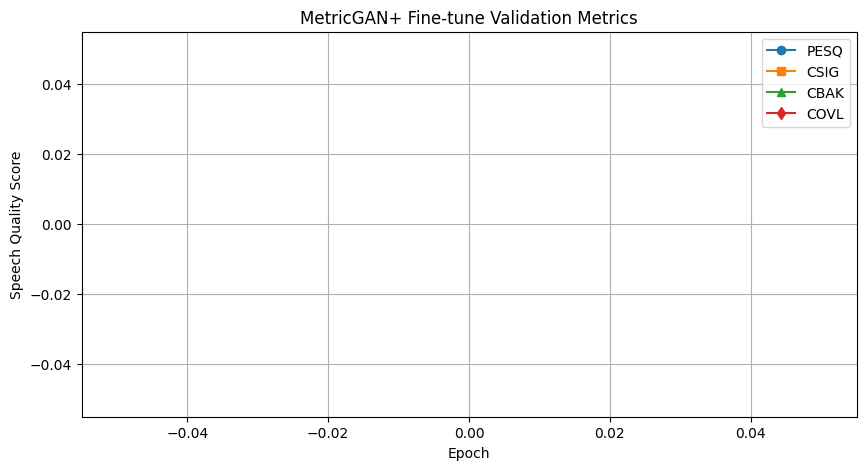

In [7]:
def plot_training_logs(log_file_path):
    if not os.path.exists(log_file_path):
        print(f"Log file not found at: {log_file_path}")
        return

    epochs, pesq_scores, csig_scores, cbak_scores, covl_scores = [], [], [], [], []

    with open(log_file_path, 'r') as f:
        for line in f:
            if 'Epoch:' in line and 'Test PESQ:' in line:
                parts = line.strip().split('|')
                try:
                    ep = int(parts[0].split(':')[1].strip())
                    pesq = float(parts[1].split(':')[1].strip())
                    csig = float(parts[2].split(':')[1].strip())
                    cbak = float(parts[3].split(':')[1].strip())
                    covl = float(parts[4].split(':')[1].strip())
                    epochs.append(ep)
                    pesq_scores.append(pesq)
                    csig_scores.append(csig)
                    cbak_scores.append(cbak)
                    covl_scores.append(covl)
                except Exception:
                    continue

    if not epochs:
        print('No evaluation metric records found in log file yet.')
        return

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, pesq_scores, 'o-', label='PESQ')
    plt.plot(epochs, csig_scores, 's-', label='CSIG')
    plt.plot(epochs, cbak_scores, '^-', label='CBAK')
    plt.plot(epochs, covl_scores, 'd-', label='COVL')
    plt.xlabel('Epoch')
    plt.ylabel('Speech Quality Score')
    plt.title('MetricGAN+ Fine-tune Validation Metrics')
    plt.grid(True)
    plt.legend()
    plt.show()
    
plot_training_logs(f'results/{args.exp_name}/log.txt')


Processing noisy audio: data/VCTK_DEMAND/test/noisy/AIHUV002-N44.wav
Weight file 'results/exp_finetune/model/best_model.pth' not found. Using random weights.


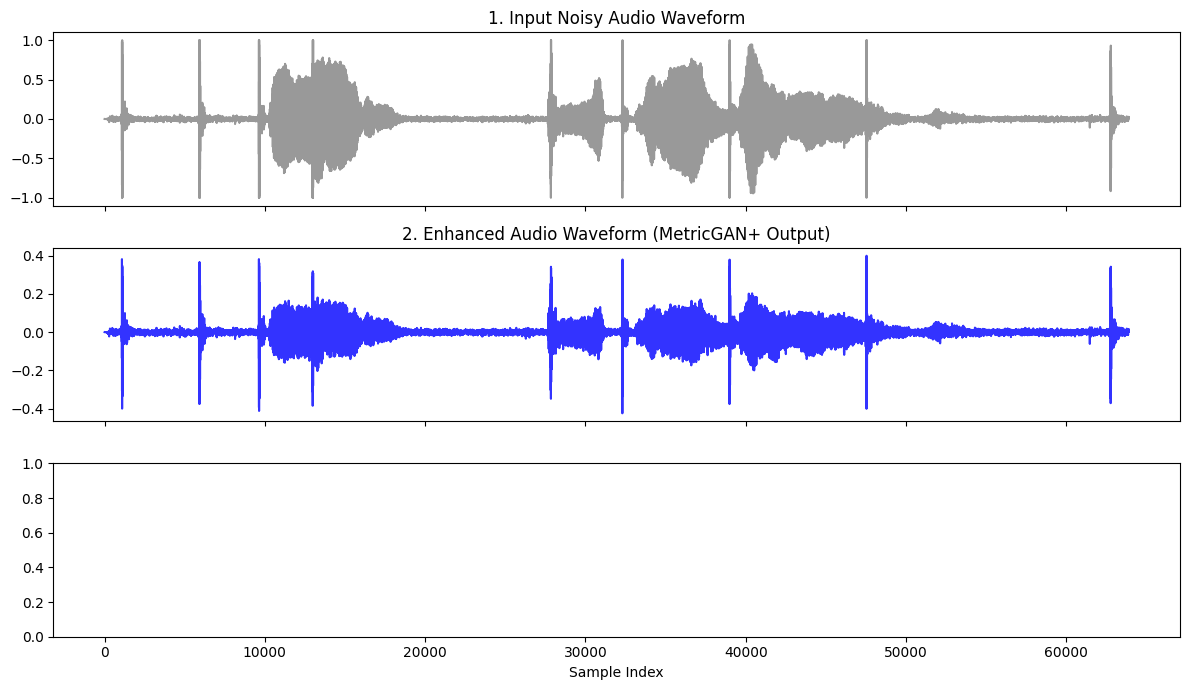

Noisy Audio:


Enhanced Audio (MetricGAN+ Output):


In [8]:
def enhance_and_evaluate_audio(weight_path=None, test_noisy_file=None, test_clean_file=None):
    if weight_path is None:
        weight_path = f'results/{args.exp_name}/model/best_model.pth'

    if test_noisy_file is None:
        noisy_files = glob.glob('data/VCTK_DEMAND/test/noisy/*.wav') or glob.glob('inputTest/*.wav')
        if not noisy_files:
            print('No test noisy files found.')
            return
        test_noisy_file = noisy_files[0]

    if test_clean_file is None:
        basename = os.path.basename(test_noisy_file)
        clean_cand = os.path.join('data/VCTK_DEMAND/test/clean', basename)
        if os.path.exists(clean_cand):
            test_clean_file = clean_cand
        elif os.path.exists(os.path.join('inputClean', basename)):
            test_clean_file = os.path.join('inputClean', basename)

    print(f'Processing noisy audio: {test_noisy_file}')

    gen = Generator(causal=False).to(device)
    if os.path.exists(weight_path):
        print(f'Loading weights from: {weight_path}')
        checkpoint = torch.load(weight_path, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'generator' in checkpoint:
            gen.load_state_dict(checkpoint['generator'])
        elif isinstance(checkpoint, dict):
            gen.load_state_dict(checkpoint)
        else:
            print('Unknown checkpoint format.')
    else:
        print(f"Weight file '{weight_path}' not found. Using random weights.")

    gen.eval()

    noisy_wav, sr = torchaudio.load(test_noisy_file)
    noisy_mag, noisy_phase = get_spec_and_phase(noisy_wav.to(device))

    with torch.no_grad():
        mask = gen(noisy_mag).clamp(min=0.05)
        enh_mag = torch.mul(mask, noisy_mag)
        enh_wav = transform_spec_to_wav(torch.expm1(enh_mag), noisy_phase, signal_length=noisy_wav.size(1))
        enh_wav = enh_wav.detach().cpu().numpy().squeeze()
        
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(noisy_wav.squeeze().numpy(), color='gray', alpha=0.8)
    axes[0].set_title('1. Input Noisy Audio Waveform')
    axes[1].plot(enh_wav, color='blue', alpha=0.8)
    axes[1].set_title('2. Enhanced Audio Waveform (MetricGAN+ Output)')

    if test_clean_file and os.path.exists(test_clean_file):
        clean_wav, _ = torchaudio.load(test_clean_file)
        axes[2].plot(clean_wav.squeeze().numpy(), color='green', alpha=0.8)
        axes[2].set_title('3. Ground Truth Clean Audio Waveform')

    plt.xlabel('Sample Index')
    plt.tight_layout()
    plt.show()

    # Interactive Audio Playback
    print('Noisy Audio:')
    ipd.display(ipd.Audio(noisy_wav.squeeze().numpy(), rate=sr))
    print('Enhanced Audio (MetricGAN+ Output):')
    ipd.display(ipd.Audio(enh_wav, rate=sr))

    if test_clean_file and os.path.exists(test_clean_file):
        clean_wav, _ = torchaudio.load(test_clean_file)
        print('Clean Reference Audio:')
        ipd.display(ipd.Audio(clean_wav.squeeze().numpy(), rate=sr))

# Chạy inference bằng checkpoint vừa Fine-tune ở trên (results/<exp_name>/model/best_model.pth)
enhance_and_evaluate_audio()
